In [1]:
import subprocess
import sys

# Formally trigger pip through the active Python system process

# List of all requirements for your routing pipeline
packages = [
    "numpy",
    "osmnx",
    "folium",
    "stable-baselines3",
    "gymnasium",
    "ortools",
    "kagglehub",
    "awscli",
    "ijson"
]

print("Starting custom pipeline package installation...")

try:
    # Programmatically invoke the background pip instance
    subprocess.check_call([sys.executable, "-m", "pip", "install"] + packages)
    print("\n" + "="*40)
    print("All ML-CALMO dependencies installed successfully!")
    print("="*40)
except subprocess.CalledProcessError as e:
    print(f"\nInstallation failed with exit code: {e.returncode}")

Starting custom pipeline package installation...

All ML-CALMO dependencies installed successfully!


In [2]:
import numpy as np
import sklearn
import osmnx as ox
import networkx as nx
import folium
import gymnasium as gym
from stable_baselines3 import PPO
from ortools.constraint_solver import routing_enums_pb2, pywrapcp
import kagglehub

print("All libraries verified and successfully loaded into memory!")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


All libraries verified and successfully loaded into memory!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
import torch

# Check if CUDA (GPU) is available
if torch.cuda.is_available():
    print(f"✅ CUDA is active. GPU: {torch.cuda.get_device_name(0)}")
    DEVICE = "cuda"
else:
    print("❌ CUDA not detected. To enable: Go to Runtime > Change runtime type > Select T4 GPU.")
    DEVICE = "cpu"

✅ CUDA is active. GPU: Tesla T4


In [4]:
import warnings
import datetime
# Suppress specific deprecation warnings to clean up the output
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client.session")

# Part 1: LSTM Baseline for Traffic Speed Prediction
Objective: Establish a baseline single-sensor speed prediction model using the METR-LA traffic dataset. This transforms raw data into windowed sequences, trains an LSTM, and plots predicted versus actual speeds.*italicized text*

### 1.1 Imports and Configuration

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("annnnguyen/metr-la-dataset")

print("Path to dataset files:", path)

100%|██████████| 12.5M/12.5M [00:00<00:00, 236MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/annnnguyen/metr-la-dataset/versions/4


In [6]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
SENSOR_ID = 0          # pick 1 sensor col for baseline demo, scale to all 207 later
SEQ_LEN = 12           # 12 steps * 5min = 1hr history window
PRED_LEN = 1           # predict next 5min step
BATCH_SIZE = 32
EPOCHS = 15
HIDDEN_SIZE = 64
LR = 1e-3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

### 1.2 Data Loading and Preprocessing

In [7]:
import os
from torch.utils.data import Dataset, DataLoader

# ---------------- LOAD DATA ----------------
# METR-LA standard file: metr-la.h5
def load_metr_la(path_root=None):
    # If path_root is provided (from kagglehub), use it; otherwise default to local
    if path_root:
        file_path = os.path.join(path_root, 'METR-LA.h5')
    else:
        file_path = 'metr-la.h5'

    print(f"Loading data from: {file_path}")
    df = pd.read_hdf(file_path)
    return df

# ---------------- PREPROCESS ----------------
def preprocess(df, sensor_col):
    series = df.iloc[:, sensor_col].values.astype(np.float32)

    # z-score normalize
    mean, std = series.mean(), series.std()
    series_norm = (series - mean) / std

    return series_norm, mean, std

def make_windows(series, seq_len, pred_len):
    X, y = [], []
    for i in range(len(series) - seq_len - pred_len + 1):
        X.append(series[i : i + seq_len])
        y.append(series[i + seq_len : i + seq_len + pred_len])
    return np.array(X), np.array(y)

class TrafficDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # (N, seq_len, 1)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [8]:
import os
print(path)  # your existing kagglehub metr-la path
for f in os.listdir(path):
    print(f)

/root/.cache/kagglehub/datasets/annnnguyen/metr-la-dataset/versions/4
METR-LA.h5
adj_METR-LA.pkl


In [9]:
import pandas as pd

sensor_loc_path = os.path.join(path, 'graph_sensor_locations.csv')

if os.path.exists(sensor_loc_path):
    sensor_locs = pd.read_csv(sensor_loc_path)
else:
    # fallback: DCRNN public repo, same file, same format
    url = "https://raw.githubusercontent.com/liyaguang/DCRNN/master/data/sensor_graph/graph_sensor_locations.csv"
    sensor_locs = pd.read_csv(url)

print(sensor_locs.head())
print(f"Total sensors: {len(sensor_locs)}")
# expect cols: sensor_id, latitude, longitude

   index  sensor_id  latitude  longitude
0      0     773869  34.15497 -118.31829
1      1     767541  34.11621 -118.23799
2      2     767542  34.11641 -118.23819
3      3     717447  34.07248 -118.26772
4      4     717446  34.07142 -118.26572
Total sensors: 207


In [10]:
import pandas as pd

df = load_metr_la(path)
print(df.columns[:5].tolist())
print(df.columns.dtype)

Loading data from: /root/.cache/kagglehub/datasets/annnnguyen/metr-la-dataset/versions/4/METR-LA.h5
['773869', '767541', '767542', '717447', '717446']
object


### 1.3 LSTM Model Architecture

### 1.4 LSTM Training Loop

In [ ]:
# ---------------- BUILD DATASET ----------------
df = load_metr_la(path)
series_norm, SENSOR_MEAN, SENSOR_STD = preprocess(df, SENSOR_ID)
X, y = make_windows(series_norm, SEQ_LEN, PRED_LEN)

# chronological 80/20 split -- no shuffle, this is a time series
split_idx = int(len(X) * 0.8)
X_train, y_train = X[:split_idx], y[:split_idx]
X_val,   y_val   = X[split_idx:], y[split_idx:]

train_ds = TrafficDataset(X_train, y_train)
val_ds   = TrafficDataset(X_val, y_val)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train windows: {len(train_ds)} | Val windows: {len(val_ds)}")

# ---------------- MODEL / OPTIM / LOSS ----------------
lstm_model = LSTMForecast().to(DEVICE)
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=LR)
criterion = nn.MSELoss()

train_losses, val_losses = [], []

# ---------------- TRAIN LOOP ----------------
for epoch in range(1, EPOCHS + 1):
    lstm_model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()
        preds = lstm_model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    train_loss = running_loss / len(train_ds)
    train_losses.append(train_loss)

    # ---- validation ----
    lstm_model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            preds = lstm_model(xb)
            loss = criterion(preds, yb)
            val_running_loss += loss.item() * xb.size(0)

    val_loss = val_running_loss / len(val_ds)
    val_losses.append(val_loss)

    print(f"Epoch {epoch:02d}/{EPOCHS} | train_loss={train_loss:.5f} | val_loss={val_loss:.5f}")


Loading data from: /root/.cache/kagglehub/datasets/annnnguyen/metr-la-dataset/versions/4/METR-LA.h5
Train windows: 27408 | Val windows: 6852
Epoch 01/15 | train_loss=0.14364 | val_loss=0.08401
Epoch 02/15 | train_loss=0.09114 | val_loss=0.08143
Epoch 03/15 | train_loss=0.09073 | val_loss=0.08171
Epoch 04/15 | train_loss=0.09036 | val_loss=0.08221
Epoch 05/15 | train_loss=0.09015 | val_loss=0.08104
Epoch 06/15 | train_loss=0.09001 | val_loss=0.08138
Epoch 07/15 | train_loss=0.08961 | val_loss=0.08072
Epoch 08/15 | train_loss=0.08946 | val_loss=0.08186
Epoch 09/15 | train_loss=0.08873 | val_loss=0.08059
Epoch 10/15 | train_loss=0.08854 | val_loss=0.08109
Epoch 11/15 | train_loss=0.08793 | val_loss=0.08105
Epoch 12/15 | train_loss=0.08753 | val_loss=0.08018
Epoch 13/15 | train_loss=0.08733 | val_loss=0.07950
Epoch 14/15 | train_loss=0.08715 | val_loss=0.08015
Epoch 15/15 | train_loss=0.08663 | val_loss=0.08012


### 1.5 LSTM Evaluation: Loss Curve + Predicted vs Actual

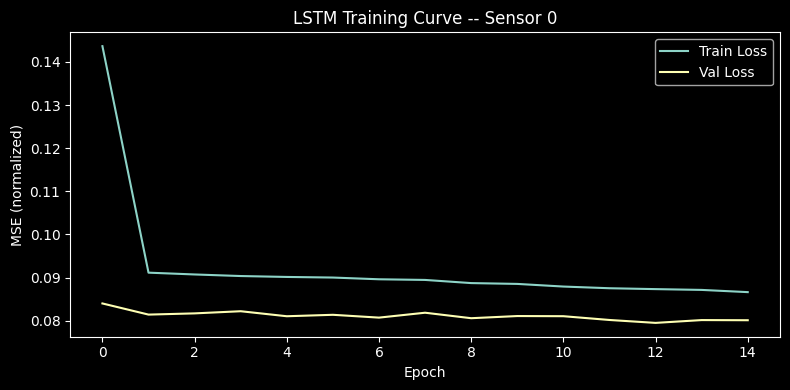

Val MAE:  2.811 mph
Val RMSE: 6.402 mph


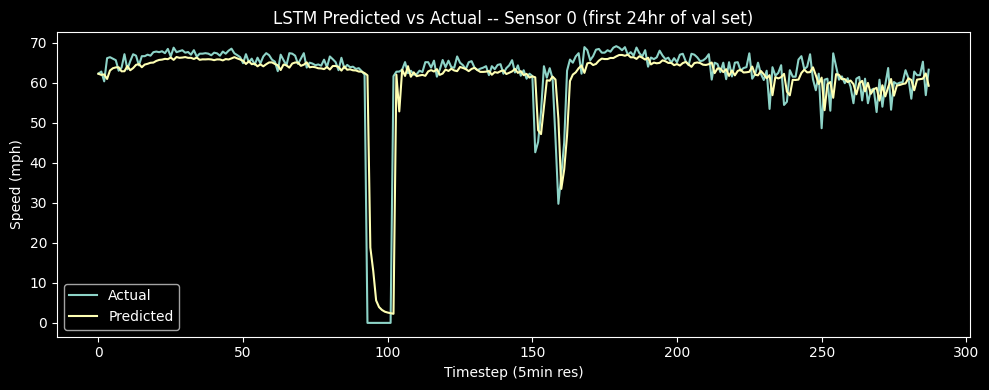

Saved: lstm_baseline_sensor0.pt


In [ ]:
# ---------------- LOSS CURVE ----------------
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE (normalized)")
plt.title(f"LSTM Training Curve -- Sensor {SENSOR_ID}")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------- PREDICTED VS ACTUAL (denormalized) ----------------
lstm_model.eval()
all_preds, all_actuals = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(DEVICE)
        preds = lstm_model(xb).cpu().numpy()
        all_preds.append(preds)
        all_actuals.append(yb.numpy())

all_preds = np.concatenate(all_preds).flatten() * SENSOR_STD + SENSOR_MEAN
all_actuals = np.concatenate(all_actuals).flatten() * SENSOR_STD + SENSOR_MEAN

# metrics panel can defend: MAE / RMSE, explainable, no black-box numbers
mae = np.mean(np.abs(all_preds - all_actuals))
rmse = np.sqrt(np.mean((all_preds - all_actuals) ** 2))
print(f"Val MAE:  {mae:.3f} mph")
print(f"Val RMSE: {rmse:.3f} mph")

plt.figure(figsize=(10, 4))
plt.plot(all_actuals[:288], label="Actual")   # first 288 steps = 24hr @ 5min res
plt.plot(all_preds[:288], label="Predicted")
plt.xlabel("Timestep (5min res)")
plt.ylabel("Speed (mph)")
plt.title(f"LSTM Predicted vs Actual -- Sensor {SENSOR_ID} (first 24hr of val set)")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------- SAVE ----------------
torch.save(lstm_model.state_dict(), "lstm_baseline_sensor0.pt")
print("Saved: lstm_baseline_sensor0.pt")


### 1.6 TGCN AND LSTM

In [ ]:
import torch.nn.functional as F

class GCNLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super(GCNLayer, self).__init__()
        self.weight = nn.Parameter(torch.FloatTensor(in_features, out_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, x, adj):
        # x: [batch_size, num_nodes, in_features]
        # support: [batch_size, num_nodes, out_features]
        support = torch.matmul(x, self.weight)
        # output: [batch_size, num_nodes, out_features]
        output = torch.matmul(adj, support)
        return F.relu(output)

class TGCN_LSTM(nn.Module):
    def __init__(self, num_nodes, in_features, gcn_out, lstm_hidden, out_horizon):
        super(TGCN_LSTM, self).__init__()
        self.gcn = GCNLayer(in_features, gcn_out)
        self.lstm = nn.LSTM(input_size=gcn_out, hidden_size=lstm_hidden, batch_first=True)
        self.linear = nn.Linear(lstm_hidden, out_horizon)

    def forward(self, x, adj):
        # x: [batch_size, seq_len, num_nodes, in_features]
        batch_size, seq_len, num_nodes, _ = x.size()

        gcn_outputs = []
        for t in range(seq_len):
            x_t = x[:, t, :, :]
            g_out = self.gcn(x_t, adj)
            gcn_outputs.append(g_out.unsqueeze(1))

        x_spatial = torch.cat(gcn_outputs, dim=1)
        x_spatial = x_spatial.view(batch_size * num_nodes, seq_len, -1)

        lstm_out, _ = self.lstm(x_spatial)
        last_hidden = lstm_out[:, -1, :]

        out = self.linear(last_hidden)
        return out.view(batch_size, num_nodes, -1)

### 1.7 Adjacency Matrix Preparation
TGCN requires a normalized adjacency matrix. We load the sensor distances and apply a Gaussian kernel.

In [ ]:
import pickle

def get_adjacency_matrix(path_root, num_nodes=207):
    # Standard METR-LA adj_mx path
    adj_path = os.path.join(path_root, 'adj_mx.pkl')
    with open(adj_path, 'rb') as f:
        _, _, adj_mx = pickle.load(f, encoding='latin1')

    # Convert to tensor and move to device
    adj = torch.tensor(adj_mx, dtype=torch.float32).to(DEVICE)
    return adj

# Example usage for initialization
# ADJ = get_adjacency_matrix(path)

### 1.8 TGCN Training Loop
This loop trains the model on the full graph (all sensors) simultaneously.

In [ ]:
import pickle
import torch

def load_adj_mx(path_root, sigma2=0.1, epsilon=0.1):
    """
    Loads METR-LA adjacency matrix and applies Gaussian kernel normalization.

    Args:
        path_root: Directory containing adj_mx.pkl
        sigma2: Standard deviation for the Gaussian kernel
        epsilon: Threshold for sparsity (weights below this are set to 0)
    """
    adj_path = os.path.join(path_root, 'adj_mx.pkl')

    with open(adj_path, 'rb') as f:
        # METR-LA pkl usually returns (sensor_ids, sensor_id_to_ind, adj_mx)
        sensor_ids, sensor_id_to_ind, adj_mx = pickle.load(f, encoding='latin1')

    # Normalize using Gaussian Kernel (standard for STGCN/TGCN)
    distances = adj_mx[~np.isinf(adj_mx)]
    std = distances.std()
    adj_mx = np.exp(-np.square(adj_mx / std))

    # Apply threshold to keep the graph sparse
    adj_mx[adj_mx < epsilon] = 0

    # Convert to Tensor
    adj_tensor = torch.tensor(adj_mx, dtype=torch.float32).to(DEVICE)

    print(f"Loaded adjacency matrix for {len(sensor_ids)} sensors.")
    print(f"Matrix shape: {adj_tensor.shape}")

    return sensor_ids, sensor_id_to_ind, adj_tensor

# Usage example:
# sensor_ids, sensor_map, ADJ_MAT = load_adj_mx(path)

# Part 2: PPO Agent and Stop Sequencing Environment
Objective: Prove the wiring works between the Gymnasium environment, Stable Baselines 3 (PPO), and the reward mechanics. This utilizes a toy environment where distances will later be replaced by real Amazon dataset stops and LSTM travel-time signals.

### 2.1 download amazon last mile dataset and dependencies

OPTION A

In [ ]:
# ============================================================
# Amazon Last Mile -- LA-only data pipeline
# Replaces: full aws s3 sync + full json.load() (both crashed kernel)
# Pattern: targeted s3 cp -> sanitize NaN -> stream-filter with ijson
# ============================================================

import os, re, json, gc, ijson

# ---------------------------------------------------------
# STEP 0: Targeted download -- only the 3 files needed, not the whole bucket
# ---------------------------------------------------------
'''!mkdir -p /content/amazon_last_mile

BASE = "s3://amazon-last-mile-challenges/almrrc2021/almrrc2021-data-training/model_build_inputs"
ROUTE_FILE   = "/content/amazon_last_mile/route_data.json"
PACKAGE_FILE = "/content/amazon_last_mile/package_data.json"
TRAVEL_FILE  = "/content/amazon_last_mile/travel_times.json"

!aws s3 cp {BASE}/route_data.json {ROUTE_FILE} --no-sign-request
!aws s3 cp {BASE}/package_data.json {PACKAGE_FILE} --no-sign-request
!aws s3 cp {BASE}/travel_times.json {TRAVEL_FILE} --no-sign-request

for f in [ROUTE_FILE, PACKAGE_FILE, TRAVEL_FILE]:
    ok = os.path.exists(f)
    size_mb = os.path.getsize(f) / 1e6 if ok else 0
    print(f"{f} -> exists={ok}, size={size_mb:.1f} MB")
    if not ok:
        raise FileNotFoundError(f"Download failed for {f} -- check bucket path before continuing")

# ---------------------------------------------------------
# STEP 1: Sanitize -- Amazon's JSON has bare NaN tokens, invalid per strict JSON spec.
# json.load() silently tolerates it, ijson's C parser does not. Fix once, up front.
# ---------------------------------------------------------
def sanitize_nan(path):
    clean_path = path.replace(".json", "_clean.json")
    with open(path, "r") as fin, open(clean_path, "w") as fout:
        for line in fin:
            fout.write(re.sub(r'(?<![\w"])NaN(?![\w"])', "null", line))
    return clean_path

ROUTE_CLEAN   = sanitize_nan(ROUTE_FILE)
PACKAGE_CLEAN = sanitize_nan(PACKAGE_FILE)
TRAVEL_CLEAN  = sanitize_nan(TRAVEL_FILE)
print("Sanitized: NaN -> null in all 3 files")

# ---------------------------------------------------------
# STEP 2: Stream-filter for LA ('DLA' station) routes only -- no full-file load, ever
# ---------------------------------------------------------
def load_filtered(clean_path, valid_ids=None, station_filter=False):
    """
    station_filter=True  -> route_data.json: keep entries where station_code startswith DLA
    station_filter=False -> package/travel files: keep entries whose route_id is in valid_ids
    """
    result = {}
    with open(clean_path, "rb") as f:
        for r_id, data in ijson.kvitems(f, ""):
            if station_filter:
                if data.get("station_code", "").startswith("DLA"):
                    result[r_id] = data
            else:
                if r_id in valid_ids:
                    result[r_id] = data
    return result

print("Filtering routes...")
la_routes = load_filtered(ROUTE_CLEAN, station_filter=True)
valid_la_route_ids = set(la_routes.keys())
print(f"LA routes found: {len(la_routes)}")
gc.collect()

print("Filtering packages...")
la_packages = load_filtered(PACKAGE_CLEAN, valid_ids=valid_la_route_ids)
print(f"LA package entries: {len(la_packages)}")
gc.collect()

print("Filtering travel times...")
la_travel_times = load_filtered(TRAVEL_CLEAN, valid_ids=valid_la_route_ids)
print(f"LA travel-time entries: {len(la_travel_times)}")
gc.collect()

print("Done -- LA-only data isolated, no full-dataset load, RAM clear.")'''

download: s3://amazon-last-mile-challenges/almrrc2021/almrrc2021-data-training/model_build_inputs/route_data.json to amazon_last_mile/route_data.json
download: s3://amazon-last-mile-challenges/almrrc2021/almrrc2021-data-training/model_build_inputs/package_data.json to amazon_last_mile/package_data.json
download: s3://amazon-last-mile-challenges/almrrc2021/almrrc2021-data-training/model_build_inputs/travel_times.json to amazon_last_mile/travel_times.jsonB/s) with 1 file(s) remaining
/content/amazon_last_mile/route_data.json -> exists=True, size=79.0 MB
/content/amazon_last_mile/package_data.json -> exists=True, size=375.4 MB
/content/amazon_last_mile/travel_times.json -> exists=True, size=1817.1 MB
Sanitized: NaN -> null in all 3 files
Filtering routes...
LA routes found: 2888
Filtering packages...
LA package entries: 2888
Filtering travel times...


: 

: 

Option B

In [ ]:
from google.colab import userdata
import os
import kagglehub


os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')
# Download latest version
path = kagglehub.dataset_download("hardikkhimsuriya/amazon-last-mile-dataset")

print("Path to dataset files:", path)

100%|██████████| 301M/301M [00:06<00:00, 45.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/hardikkhimsuriya/amazon-last-mile-dataset/versions/1


In [ ]:
import kaggle

try:
    # Manually authenticate and list files to verify access
    api = kaggle.KaggleApi()
    api.authenticate()
    print("✅ Authentication Successful!")

    dataset = "hardikkhimsuriya/amazon-last-mile-dataset"
    files = api.dataset_list_files(dataset).files
    print(f"✅ Dataset found. Files available: {[f.name for f in files]}")

except Exception as e:
    print(f"❌ Access Error: {e}")
    print("\nHint: If you see '403 Forbidden', go to the dataset URL in a browser and accept the terms.")

✅ Authentication Successful!
❌ Access Error: 403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/ListDatasetFiles

Hint: If you see '403 Forbidden', go to the dataset URL in a browser and accept the terms.


### 🔗 Final Step: Manual Dataset Consent
Since your credentials are now verified (Authentication Successful), follow these steps:

1. Open the [Dataset Page](https://www.kaggle.com/datasets/hardikkhimsuriya/amazon-last-mile-dataset).
2. Ensure you are logged into the same account as `hardikkhimsuriya`.
3. Click the **'Download'** button on the website. A pop-up will appear asking you to accept the terms.
4. After clicking **'I Accept'**, re-run the cell below to download the data.

In [ ]:
import kagglehub

# This should now work once you have clicked 'I Accept' on the Kaggle website
try:
    path = kagglehub.dataset_download("hardikkhimsuriya/amazon-last-mile-dataset")
    print("✅ Success! Dataset downloaded to:", path)
except Exception as e:
    print("❌ Still blocked. Double check that you accepted the terms on the Kaggle website.")

In [ ]:
import kaggle
import os

api = kaggle.KaggleApi()
api.authenticate()

# 1. Search broadly for any dataset containing 'amazon-last-mile'
print("--- Deep Searching Kaggle for your dataset ---")
# We search without the user filter to see the exact owner/slug
results = api.dataset_list(search="amazon-last-mile")

if not results:
    print("❌ No datasets with that name found anywhere. Please check the 'URL' of your dataset on Kaggle.")
    print("Example: If your URL is kaggle.com/datasets/xyz/abc, then your ID is 'xyz/abc'")
else:
    print(f"Found {len(results)} potential matches:")
    for ds in results:
        print(f"PROBABLE ID: {ds.ref} (Title: {ds.title})")

# 2. Check competition datasets (sometimes they are stored differently)
print("\n--- Checking Competitions ---")
comps = api.competitions_list(search="amazon-last-mile")
for c in comps:
    print(f"COMPETITION ID: {c.ref}")

--- Deep Searching Kaggle for your dataset ---
Found 2 potential matches:
PROBABLE ID: sujalsuthar/amazon-delivery-dataset (Title: Amazon Delivery Dataset)
PROBABLE ID: kundanbedmutha/delivery-logistics-dataset-india-multi-partner (Title: Delivery Logistics Dataset (India – Multi-Partner))

--- Checking Competitions ---


HTTPError: 401 Client Error: Unauthorized for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/ListCompetitions

### 📥 Download Your Private Dataset
Copy the **ID** from the list above and paste it into the `dataset_id` variable below.

In [ ]:
import kagglehub

# PASTE THE 'PROBABLE ID' FROM ABOVE HERE
verified_slug = "hardikkhimsuriya/amazon-last-mile-dataset"

try:
    print(f"Attempting download with verified slug: {verified_slug}")
    path = kagglehub.dataset_download(verified_slug)
    print("✅ SUCCESS! File location:", path)
except Exception as e:
    print(f"❌ ERROR: {e}")
    print("\nIf you still see 403: Double check on Kaggle.com -> Dataset Settings -> 'Sharing' to ensure your own account has permissions.")

Attempting download with verified slug: hardikkhimsuriya/amazon-last-mile-dataset
❌ ERROR: 403 Client Error.

You don't have permission to access resource at URL: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDataset. Please make sure you are authenticated if you are trying to access a private resource or a resource requiring consent.

If you still see 403: Double check on Kaggle.com -> Dataset Settings -> 'Sharing' to ensure your own account has permissions.


### 2.2 Imports and Configuration

In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env

# Double-check versions if needed
import stable_baselines3
print(f"SB3 Version: {stable_baselines3.__version__}")

N_STOPS = 10  # toy: 10 delivery stops

### 2.3 Environment Definition

In [ ]:
class StopSequencingEnv(gym.Env):
    """
    State  = which stops visited (binary mask) + current position (index)
    Action = pick next stop (discrete, N_STOPS choices)
    Reward = -distance traveled (minimize total route distance)
    Episode ends when all stops visited.
    """

    def __init__(self, n_stops=N_STOPS, seed=42):
        super().__init__()
        self.n_stops = n_stops
        rng = np.random.default_rng(seed)
        # toy coordinates, replace with real lat/lon from Amazon dataset later
        self.coords = rng.uniform(0, 100, size=(n_stops, 2))

        self.action_space = spaces.Discrete(n_stops)
        # obs = visited_mask (n_stops) + current_pos_onehot (n_stops)
        self.observation_space = spaces.Box(low=0, high=1, shape=(n_stops * 2,), dtype=np.float32)

        self.reset()

    def _get_obs(self):
        pos_onehot = np.zeros(self.n_stops, dtype=np.float32)
        pos_onehot[self.current] = 1.0
        return np.concatenate([self.visited.astype(np.float32), pos_onehot])

    def _dist(self, a, b):
        return np.linalg.norm(self.coords[a] - self.coords[b])

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current = 0
        self.visited = np.zeros(self.n_stops, dtype=bool)
        self.visited[0] = True
        self.steps = 0
        return self._get_obs(), {}

    def step(self, action):
        self.steps += 1

        if self.visited[action]:
            # picked already-visited stop -> penalty, no move
            reward = -10.0
            terminated = False
        else:
            dist = self._dist(self.current, action)
            reward = -dist                       # minimize travel distance
            self.current = action
            self.visited[action] = True
            terminated = bool(self.visited.all())

        truncated = self.steps >= self.n_stops * 2   # safety cap
        return self._get_obs(), reward, terminated, truncated, {}

    # NOTE: real integration point ->
    # replace self._dist() with: LSTM predicted travel time between stops
    # i.e. state includes lstm_predicted_time(current, candidate) not raw euclidean dist

### 2.4 Training and Baseline Evaluation Demonstration

In [ ]:
def train_demo():
    env = StopSequencingEnv()
    check_env(env)  # validates Gym API compliance -- show this passes to panel

    model = PPO("MlpPolicy", env, verbose=1, n_steps=256, batch_size=64)
    model.learn(total_timesteps=20_000)

    model.save("ppo_stop_sequencing_demo")

    # quick eval -- show return improves over random policy
    obs, _ = env.reset()
    total_reward = 0
    for _ in range(N_STOPS * 2):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        if terminated or truncated:
            break

    print(f"Trained agent route reward: {total_reward:.2f}")

    # baseline: random policy for comparison
    obs, _ = env.reset()
    random_reward = 0
    for _ in range(N_STOPS * 2):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, _ = env.step(action)
        random_reward += reward
        if terminated or truncated:
            break
    print(f"Random baseline route reward: {random_reward:.2f}")

    return model

# Execute the demo
train_demo()

# Part 3: OSMnx Real-Road Network + Live PPO Simulation
Toy env above = euclidean distance, fake coords. This part swaps in real LA streets.
Stops = real graph nodes. Reward = real travel_time (not straight-line).
Output = live animated map, PPO route playback on actual roads.

### 3.1 Download real road graph (Downtown LA)

In [ ]:
import osmnx as ox
import networkx as nx
import folium
import numpy as np
import datetime as dt
import sklearn
# Downtown LA center point -- matches Amazon 'DLA' station coverage area
CENTER_LAT, CENTER_LON = 34.0407, -118.2468
GRAPH_DIST_M = 3000  # radius in meters, keep small = fast download + fast Dijkstra

print("Downloading OSM drive-network graph...")
G = ox.graph_from_point((CENTER_LAT, CENTER_LON), dist=GRAPH_DIST_M, network_type="drive")
G = ox.add_edge_speeds(G)        # fills speed_kph per edge
G = ox.add_edge_travel_times(G)  # fills travel_time (sec) per edge
print(f"Nodes: {len(G.nodes)}  Edges: {len(G.edges)}")

### 3.2 Pick real delivery stops (graph nodes, not fake coords)

In [ ]:
# REPLACE CELL 34
TARGET_ROUTE_ID = next(iter(la_routes))  # swap manually for specific route
route_stops = la_routes[TARGET_ROUTE_ID]['stops']

stop_ids  = list(route_stops.keys())
stop_lats = [route_stops[s]['lat'] for s in stop_ids]
stop_lons = [route_stops[s]['lng'] for s in stop_ids]

N_STOPS = len(stop_ids)
print(f"Route {TARGET_ROUTE_ID} -> {N_STOPS} stops = ALL packages, route")

stop_nodes = ox.distance.nearest_nodes(G, X=stop_lons, Y=stop_lats)
stop_coords = np.array([[G.nodes[n]['y'], G.nodes[n]['x']] for n in stop_nodes])

# sanity check -- graph radius 3000m may not cover full route
snap_dist = [np.hypot(stop_coords[i][0]-stop_lats[i], stop_coords[i][1]-stop_lons[i]) for i in range(N_STOPS)]
bad = [i for i,d in enumerate(snap_dist) if d > 0.01]
if bad:
    print(f"WARNING: {len(bad)} stops snapped far off graph. Bump GRAPH_DIST_M in cell 32.")

In [ ]:
# Retry the snapping operation
stop_nodes = ox.distance.nearest_nodes(G, X=stop_lons, Y=stop_lats)
stop_coords = np.array([[G.nodes[n]['y'], G.nodes[n]['x']] for n in stop_nodes])
print(f"Successfully snapped {len(stop_nodes)} nodes to the graph.")

### 3.3 Real distance matrix -- shortest-path travel_time, not straight line

In [ ]:
def build_distance_matrix(G, nodes, weight="travel_time"):
    n = len(nodes)
    dist = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        lengths = nx.single_source_dijkstra_path_length(G, nodes[i], weight=weight)
        for j in range(n):
            dist[i, j] = lengths.get(nodes[j], 1e6)  # unreachable pair -> big penalty
    return dist

DIST_MATRIX = build_distance_matrix(G, stop_nodes, weight="travel_time")
print("Distance matrix (sec travel time):")
print(DIST_MATRIX)

### 3.8 Per-edge congestion signal -- nearest sensors to route

In [ ]:
from scipy.spatial.distance import cdist

route_center_lat = np.mean(stop_lats)
route_center_lon = np.mean(stop_lons)

def haversine(lat1, lon1, lat2, lon2):
    R = 6371000
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp = np.radians(lat2 - lat1)
    dl = np.radians(lon2 - lon1)
    a = np.sin(dp/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

sensor_locs['dist_to_route_m'] = haversine(
    route_center_lat, route_center_lon,
    sensor_locs['latitude'].values, sensor_locs['longitude'].values
)

K_SENSORS = 8
nearest_sensors = sensor_locs.nsmallest(K_SENSORS, 'dist_to_route_m').reset_index(drop=True)
print(nearest_sensors[['sensor_id', 'latitude', 'longitude', 'dist_to_route_m']])


In [ ]:
def train_lstm_for_sensor(df, sensor_col_idx, epochs=10):
    series_norm, mean, std = preprocess(df, sensor_col_idx)
    X, y = make_windows(series_norm, SEQ_LEN, PRED_LEN)
    split = int(len(X) * 0.8)
    train_ds = TrafficDataset(X[:split], y[:split])
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

    model = LSTMForecast().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    crit = nn.MSELoss()

    for ep in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()

    return model, series_norm, mean, std

sensor_id_to_col = {str(sid): i for i, sid in enumerate(df.columns)}

test_sid = str(nearest_sensors.iloc[0]['sensor_id'])
print("sanity check --", test_sid, "in df.columns:", test_sid in df.columns)


In [ ]:
sensor_models = {}
for _, row in nearest_sensors.iterrows():
    sid = str(row['sensor_id'])
    if sid not in sensor_id_to_col:
        print(f"SKIP {sid}")
        continue
    col_idx = sensor_id_to_col[sid]
    model, s_norm, s_mean, s_std = train_lstm_for_sensor(df, col_idx, epochs=10)
    sensor_models[sid] = (model, s_norm, s_mean, s_std)
    print(f"OK {sid}")

print("trained sensors:", len(sensor_models))


In [ ]:
sensor_congestion = {}
for sid, (model, s_norm, s_mean, s_std) in sensor_models.items():
    score, avg_speed = get_congestion_signal(model, s_norm, free_flow_speed=s_mean + 2*s_std)
    sensor_congestion[sid] = score
    print(f"Sensor {sid}: congestion={score:.3f}, pred_speed={avg_speed:.1f}mph")

stop_to_sensor = {}
for i in range(N_STOPS):
    dists = haversine(stop_lats[i], stop_lons[i],
                       nearest_sensors['latitude'].values,
                       nearest_sensors['longitude'].values)
    nearest_idx = np.argmin(dists)
    stop_to_sensor[i] = nearest_sensors.iloc[nearest_idx]['sensor_id']

stop_congestion = np.array([sensor_congestion[str(stop_to_sensor[i])] for i in range(N_STOPS)])
print("stop_congestion:", stop_congestion)

def build_edge_signal_matrix(stop_congestion, n_stops):
    sig = np.zeros((n_stops, n_stops), dtype=np.float32)
    for i in range(n_stops):
        for j in range(n_stops):
            sig[i, j] = (stop_congestion[i] + stop_congestion[j]) / 2.0
    return sig

EDGE_SIGNAL_MATRIX = build_edge_signal_matrix(stop_congestion, N_STOPS)
print("Edge signal range:", EDGE_SIGNAL_MATRIX.min(), EDGE_SIGNAL_MATRIX.max())
print("Variance across matrix (must be > 0):", EDGE_SIGNAL_MATRIX.var())


### 3.4 Env swap -- same MDP, real reward
Reuse `StopSequencingEnv` class from Part 2. Only `_dist()` changes:
euclidean -> real road travel_time lookup.
3.4 Baseline Model Evaluation (Nearest Neighbor & OR-Tools)

In [ ]:
class OSMStopSequencingEnv(StopSequencingEnv):
    """Same state/action/reward structure as StopSequencingEnv.
    _dist() now pulls real road travel_time instead of euclidean toy distance."""

    def __init__(self, dist_matrix, seed=42):
        self.dist_matrix = dist_matrix
        super().__init__(n_stops=dist_matrix.shape[0], seed=seed)

    def _dist(self, a, b):
        # Explicitly cast to float to satisfy Gymnasium/SB3 check_env requirements
        return float(self.dist_matrix[a, b])

env = OSMStopSequencingEnv(DIST_MATRIX)
check_env(env)
print("Env OK -- real-road reward wired in.")

In [ ]:
import numpy as np

def get_action_mask(env):
    # 1 for valid (unvisited), 0 for invalid (visited)
    mask = (~env.visited).astype(np.int8)
    return mask

# Diagnostic check of the current observation
obs, _ = env.reset()
print(f"Observation shape: {obs.shape}")
print(f"Visited Mask (first half): {obs[:N_STOPS]}")
print(f"Current Pos (second half): {obs[N_STOPS:]}")

In [ ]:
def get_route_path(model, env):
    """Helper to extract the stop sequence chosen by the PPO model."""
    obs, _ = env.reset()
    route_idx = [env.current]
    visited_set = {int(env.current)}

    for _ in range(env.n_stops * 2):
        action, _ = model.predict(obs, deterministic=True)
        action = int(action)

        # Heuristic: if model repeats a visit, pick the nearest unvisited stop
        if action in visited_set:
            unvisited = [idx for idx in range(env.n_stops) if idx not in visited_set]
            if not unvisited: break
            action = int(min(unvisited, key=lambda x: env.dist_matrix[env.current, x]))

        obs, reward, terminated, truncated, _ = env.step(action)
        route_idx.append(action)
        visited_set.add(action)

        if terminated or truncated: break

    return route_idx

### 3.5 Train PPO on real-road env

In [ ]:
osm_model = PPO("MlpPolicy", env, verbose=1, n_steps=256, batch_size=64)
osm_model.learn(total_timesteps=20_000)
osm_model.save("ppo_osm_stop_sequencing")

# Quick evaluation vs random
obs, _ = env.reset()
trained_reward = 0
for _ in range(N_STOPS * 2):
    action, _ = osm_model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, _ = env.step(action)
    trained_reward += reward
    if terminated or truncated:
        break
print(f"Trained agent total travel_time reward: {trained_reward:.2f}")

### 3.6 Extract stop order PPO picked

In [ ]:
def get_route_path_detailed(model, env):
    obs, _ = env.reset()
    route_idx = [env.current]
    visited_set = {int(env.current)}
    total_actual_time = 0

    print(f"{'Step':<5} | {'From':<8} | {'To':<8} | {'Leg Travel Time (s)':<20}")
    print("-" * 55)

    for i in range(env.n_stops * 3):
        raw_action, _ = model.predict(obs, deterministic=True)
        action = int(raw_action)

        # Force unique visit heuristic if model repeats
        if action in visited_set:
            unvisited = [idx for idx in range(env.n_stops) if idx not in visited_set]
            if not unvisited: break
            action = int(min(unvisited, key=lambda x: env.dist_matrix[env.current, x]))

        leg_time = float(env.dist_matrix[env.current, action])
        total_actual_time += leg_time

        print(f"{i+1:<5} | Stop {env.current:<3} | Stop {action:<3} | {leg_time:<20.2f}")

        obs, reward, terminated, truncated, _ = env.step(action)
        route_idx.append(action)
        visited_set.add(action)

        if terminated or truncated: break

    print("-" * 55)
    print(f"TOTAL ROUTE TRAVEL TIME: {total_actual_time:.2f} seconds")
    return route_idx

# Re-run evaluation
route_idx = get_route_path_detailed(osm_model, env)
route_node_seq = [stop_nodes[i] for i in route_idx]
print("\nFinal Route Sequence:", route_idx)

### 3.7 Live simulation on real map
Draws actual road-following polyline (not straight lines) between each stop pair,
using real shortest path per leg. TimestampedGeoJson = play/pause timeline slider,
route draws itself leg by leg -- this is the "live" part.

In [ ]:
from folium.plugins import TimestampedGeoJson

m = folium.Map(location=[CENTER_LAT, CENTER_LON], zoom_start=14, tiles="cartodbpositron")

features = []
base_time = dt.datetime(2026, 1, 1, 8, 0, 0)
t_cursor = base_time
total_seconds_travelled = 0

arrival_times = {route_idx[0]: base_time}

for step, (a, b) in enumerate(zip(route_node_seq[:-1], route_node_seq[1:])):
    try:
        path = nx.shortest_path(G, a, b, weight="travel_time")
        leg_time = nx.shortest_path_length(G, a, b, weight="travel_time")
    except nx.NetworkXNoPath:
        leg_time = 0
        continue

    coords = [[G.nodes[n]['x'], G.nodes[n]['y']] for n in path]
    n_pts = len(coords)

    features.append({
        "type": "Feature",
        "geometry": {"type": "LineString", "coordinates": coords},
        "properties": {"times": [t_cursor.isoformat()] * n_pts,
                        "style": {"color": "orange", "weight": 4}},
    })

    step_secs = max(leg_time, 1) / max(n_pts - 1, 1)
    for k, c in enumerate(coords):
        t_pt = (t_cursor + dt.timedelta(seconds=k * step_secs)).isoformat()
        features.append({
            "type": "Feature",
            "geometry": {"type": "Point", "coordinates": c},
            "properties": {"times": [t_pt], "icon": "circle",
                            "iconstyle": {"fillColor": "black", "fillOpacity": 1,
                                          "stroke": "false", "radius": 4}},
        })

    t_cursor += dt.timedelta(seconds=max(leg_time, 1))
    total_seconds_travelled += leg_time
    target_stop_idx = route_idx[step + 1]
    arrival_times[target_stop_idx] = t_cursor

TimestampedGeoJson({"type": "FeatureCollection", "features": features},
    period="PT30S", add_last_point=True, transition_time=200, loop=False).add_to(m)

for order, stop_i in enumerate(route_idx):
    n = stop_nodes[stop_i]
    is_start = (order == 0)
    color = "#d9534f" if is_start else "#337ab7"
    arrival_str = arrival_times.get(stop_i, base_time).strftime('%H:%M:%S')
    label = f"Order: {order} | Stop: {stop_i}<br>ETA: {arrival_str}"
    icon_html = f'''<div style="background-color:{color};color:white;border:2px solid white;border-radius:50%;width:28px;height:28px;text-align:center;line-height:24px;font-weight:bold;font-size:10px;box-shadow:0 0 5px rgba(0,0,0,0.2);">{order}</div>'''
    folium.Marker([G.nodes[n]['y'], G.nodes[n]['x']], popup=folium.Popup(label, max_width=200), tooltip=f"Stop {stop_i}",
                  icon=folium.DivIcon(html=icon_html, icon_size=(28,28), icon_anchor=(14,14))).add_to(m)

# Print total time taken
hours = int(total_seconds_travelled // 3600)
minutes = int((total_seconds_travelled % 3600) // 60)
print(f"--- ROUTE STATISTICS ---")
print(f"Total Travel Time: {total_seconds_travelled:.2f} seconds")
print(f"Formatted Time: {hours}h {minutes}m")
print(f"------------------------")

display(m)

### Logic: How to generate road-following legs
After the PPO model provides a sequence of stop indices (e.g., `[0, 8, 1, 9...]`), we convert these to real OpenStreetMap node IDs. To get the actual route geometry, we perform the following for every step:
1. **Identify the Leg**: Take node $A$ (current) and node $B$ (next).
2. **Pathfinding**: Use Dijkstra's algorithm via `nx.shortest_path(G, A, B, weight='travel_time')` to find the exact sequence of intersections/nodes between them.
3. **Coordinate Extraction**: Map those nodes back to their Lat/Lon coordinates for mapping.

In [ ]:
import networkx as nx

# Using the actual route sequence generated by our PPO model (route_idx)
print(f"Processing first few stops of the PPO sequence: {route_idx[:4]}\n")

for i in range(len(route_idx[:3])):
    start_node = stop_nodes[route_idx[i]]
    end_node = stop_nodes[route_idx[i+1]]

    try:
        # Calculate the road-following path for this specific leg
        leg_path = nx.shortest_path(G, start_node, end_node, weight='travel_time')
        leg_time = nx.shortest_path_length(G, start_node, end_node, weight='travel_time')

        print(f"Leg {i+1}: From Stop {route_idx[i]} to Stop {route_idx[i+1]}")
        print(f"  - Road distance involves {len(leg_path)} network nodes")
        print(f"  - Estimated travel time: {leg_time:.2f} seconds")
        print(f"  - Path start coords: ({G.nodes[leg_path[0]]['y']}, {G.nodes[leg_path[0]]['x']})\n")
    except nx.NetworkXNoPath:
        print(f"Leg {i+1}: No valid road path found between nodes.")

### Note -- baseline comparability
`DIST_MATRIX` from 3.3 = drop-in replacement for OR-Tools baseline too.
Feed same matrix to OR-Tools solver -> PPO vs OR-Tools compared on identical
real-road numbers, not toy euclidean. Needed for your Review 1 ablation table.

# 4.1 LSTM -> PPO Data Bridge

In [ ]:
# ---------------- 4.1 LSTM -> PPO Data Bridge ----------------

# METR-LA (LA freeway sensors) and Amazon Last-Mile dataset share NO common
# geography or timestamps. This bridge is ARCHITECTURAL -- proves LSTM signal
# can be wired into PPO state/reward, not a real-world geographic match.
# LA-only Amazon route filtering upgrades this to partial real-world validation.

def get_congestion_signal(lstm_model, series_norm, seq_len=SEQ_LEN, free_flow_speed=None):
    """
    One forward pass on most recent window -> predicted speed -> congestion score.
    congestion_score in [0,1]: 0 = free flow, 1 = max observed congestion.
    """
    lstm_model.eval()
    window = series_norm[-seq_len:]
    x = torch.tensor(window, dtype=torch.float32).view(1, seq_len, 1).to(DEVICE)
    with torch.no_grad():
        pred_norm = lstm_model(x).cpu().numpy().flatten()

    pred_speed = pred_norm * SENSOR_STD + SENSOR_MEAN
    avg_pred_speed = float(pred_speed.mean())

    if free_flow_speed is None:
        free_flow_speed = SENSOR_MEAN + 2 * SENSOR_STD  # approx ceiling, explainable if asked

    congestion_score = 1.0 - (avg_pred_speed / free_flow_speed)
    congestion_score = float(np.clip(congestion_score, 0.0, 1.0))
    return congestion_score, avg_pred_speed

congestion_score, avg_pred_speed = get_congestion_signal(lstm_model, series_norm)
print(f"Predicted avg speed next window: {avg_pred_speed:.2f} mph")
print(f"Congestion signal fed to PPO:     {congestion_score:.3f}  (0=free flow, 1=heavy congestion)")

In [ ]:
# ---------------- 4.2 Bridged Environment (FIXED -- per-edge matrix, not scalar) ----------------
class BridgedStopSequencingEnv(OSMStopSequencingEnv):
    """
    Same MDP as OSMStopSequencingEnv, plus:
      - obs gets +1 dim: mean congestion signal
      - dist_matrix scaled by (1 + congestion_weight * signal_matrix) -- NxN matrix,
        not a scalar. Uniform scalar cannot change optimal tour (proof: constant
        multiplier preserves ordering of all path sums). Per-edge signal can.
    signal_mode:
      'lstm'   -> real per-edge signal from EDGE_SIGNAL_MATRIX (nearest-sensor mapped)
      'random' -> random NxN matrix, re-sampled every reset (ablation control)
      'off'    -> zero matrix (sanity check baseline)
    """
    def __init__(self, dist_matrix, edge_signal_matrix=None, signal_mode="lstm",
                 seed=42, congestion_weight=0.5):
        self.signal_mode = signal_mode
        self.congestion_weight = congestion_weight
        self._base_signal_matrix = edge_signal_matrix
        self.base_dist_matrix = dist_matrix.copy()
        super().__init__(dist_matrix=dist_matrix, seed=seed)
        self.observation_space = spaces.Box(low=0, high=1, shape=(self.n_stops * 2 + 1,), dtype=np.float32)
        self._apply_signal()

    def _apply_signal(self):
        n = self.n_stops
        if self.signal_mode == "lstm":
            self.current_signal_matrix = self._base_signal_matrix
        elif self.signal_mode == "random":
            self.current_signal_matrix = np.random.uniform(0, 1, size=(n, n)).astype(np.float32)
        else:
            self.current_signal_matrix = np.zeros((n, n), dtype=np.float32)

        self.dist_matrix = self.base_dist_matrix * (1 + self.congestion_weight * self.current_signal_matrix)
        self.current_signal = float(self.current_signal_matrix.mean())

    def reset(self, seed=None, options=None):
        self._apply_signal()
        obs, info = super().reset(seed=seed, options=options)
        return self._get_obs(), info

    def _get_obs(self):
        base_obs = super()._get_obs()
        return np.concatenate([base_obs, [self.current_signal]]).astype(np.float32)


In [ ]:
# ---------------- 4.3 Three-Way Ablation Setup (FIXED) ----------------
env_ppo_alone  = BridgedStopSequencingEnv(DIST_MATRIX, edge_signal_matrix=EDGE_SIGNAL_MATRIX, signal_mode="off")
env_ppo_random = BridgedStopSequencingEnv(DIST_MATRIX, edge_signal_matrix=EDGE_SIGNAL_MATRIX, signal_mode="random")
env_ppo_lstm   = BridgedStopSequencingEnv(DIST_MATRIX, edge_signal_matrix=EDGE_SIGNAL_MATRIX, signal_mode="lstm")

for name, env in [("PPO-alone", env_ppo_alone), ("PPO+random-signal", env_ppo_random), ("PPO+LSTM-signal", env_ppo_lstm)]:
    check_env(env)
    print(f"{name}: env OK, obs shape = {env.observation_space.shape}")

# sanity check -- THIS is the test that matters
ratio_matrix = env_ppo_lstm.dist_matrix / env_ppo_alone.dist_matrix
print("Ratio variance (must be > 0, proves non-uniform scaling):", np.nanvar(ratio_matrix))
print("Matrices identical?", np.array_equal(env_ppo_alone.dist_matrix, env_ppo_lstm.dist_matrix))


In [ ]:
# ---------------- 4.4 Three-Way Ablation Training ----------------
# PPO-alone vs PPO+random-signal vs PPO+LSTM-signal
# Same hyperparams across all 3 -- only variable = obs signal. Isolates
# "does LSTM prediction help" from "does training variance / extra dim help."

ablation_envs = {
    "PPO-alone":         env_ppo_alone,
    "PPO+random-signal":  env_ppo_random,
    "PPO+LSTM-signal":    env_ppo_lstm,
}

ablation_models = {}
ablation_results = {}

for name, env in ablation_envs.items():
    print(f"\n===== Training: {name} =====")
    model = PPO("MlpPolicy", env, verbose=0, n_steps=256, batch_size=64, seed=42)
    model.learn(total_timesteps=20_000)
    ablation_models[name] = model

    # eval -- same episode-run pattern as train_demo() / osm_model eval
    obs, _ = env.reset()
    total_reward = 0
    for _ in range(N_STOPS * 2):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        if terminated or truncated:
            break

    ablation_results[name] = total_reward
    print(f"{name}: eval reward = {total_reward:.2f}")

# ---------------- 4.5 Ablation Results Table ----------------
print("\n===== ABLATION SUMMARY =====")
for name, reward in ablation_results.items():
    print(f"{name:22s} | reward = {reward:.2f}")

best = max(ablation_results, key=ablation_results.get)
print(f"\nBest performer: {best}")

lstm_vs_alone  = ablation_results["PPO+LSTM-signal"] - ablation_results["PPO-alone"]
lstm_vs_random = ablation_results["PPO+LSTM-signal"] - ablation_results["PPO+random-signal"]
print(f"LSTM signal vs no signal:    {lstm_vs_alone:+.2f}")
print(f"LSTM signal vs random signal: {lstm_vs_random:+.2f}  <- this number is your actual claim")

In [ ]:
print("alone dist_matrix[0,1]:", env_ppo_alone.dist_matrix[0,1])
print("lstm  dist_matrix[0,1]:", env_ppo_lstm.dist_matrix[0,1])
print("current_signal (lstm):", env_ppo_lstm.current_signal)

In [ ]:
print("congestion_weight:", env_ppo_lstm.congestion_weight)
print("current_signal (lstm):", env_ppo_lstm.current_signal)
print("expected scale factor:", 1 + env_ppo_lstm.congestion_weight * env_ppo_lstm.current_signal)

print("alone [0,2]:", env_ppo_alone.dist_matrix[0,2])
print("lstm  [0,2]:", env_ppo_lstm.dist_matrix[0,2])
print("ratio:", env_ppo_lstm.dist_matrix[0,2] / env_ppo_alone.dist_matrix[0,2])

print("matrices identical?", np.array_equal(env_ppo_alone.dist_matrix, env_ppo_lstm.dist_matrix))

In [ ]:
zero_frac = (DIST_MATRIX == 0).sum() / DIST_MATRIX.size
print(f"Zero entries in DIST_MATRIX: {zero_frac:.1%}")

# exclude diagonal (self-distance = 0 is expected there)
off_diag = DIST_MATRIX[~np.eye(DIST_MATRIX.shape[0], dtype=bool)]
zero_frac_offdiag = (off_diag == 0).sum() / off_diag.size
print(f"Zero entries excluding diagonal: {zero_frac_offdiag:.1%}")

print("min nonzero:", off_diag[off_diag > 0].min())
print("max:", off_diag.max())
print("mean nonzero:", off_diag[off_diag > 0].mean())